# EP1 - EDA del catálogo StreamView Analytics

Este notebook es independiente de la limpieza inicial. Lee los archivos procesados de `data/processed/` y responde las preguntas del caso: composición, géneros, popularidad, valoración, finanzas y mercados.

**Audiencias:** Directorio, Gerencia de Contenidos y Marketing. `popularity` se interpreta como índice relativo, no como reproducciones.

In [10]:
import os
import numpy as np
import pandas as pd

working_dir = os.getcwd()
ROOT = os.path.abspath(os.path.join(working_dir, '..')) if os.path.basename(working_dir).lower() == 'notebooks' else working_dir
PROCESSED = os.path.join(ROOT, 'data', 'processed')
IMAGES = os.path.join(ROOT, 'images')
DOCS = os.path.join(ROOT, 'documentation', 'markdown')
os.makedirs(IMAGES, exist_ok=True)
os.makedirs(DOCS, exist_ok=True)

movies_file = os.path.join(PROCESSED, 'movies_processed.csv')
tv_file = os.path.join(PROCESSED, 'tv_processed.csv')
if not all(os.path.exists(path) for path in [movies_file, tv_file]):
    raise FileNotFoundError('Ejecuta primero notebooks/EP1_initial_cleaning_colab.ipynb para crear data/processed/.')

movies = pd.read_csv(movies_file, low_memory=False)
tv = pd.read_csv(tv_file, low_memory=False)
movies['type'] = 'Movie'
tv['type'] = 'TV Show'
catalog = pd.concat([movies, tv], ignore_index=True)
catalog['date_added'] = pd.to_datetime(catalog['date_added'], errors='coerce')
for column in ['release_year', 'popularity', 'vote_average', 'vote_count', 'budget', 'revenue']:
    if column in catalog.columns:
        catalog[column] = pd.to_numeric(catalog[column], errors='coerce')

def explode_dimension(dataframe, column):
    columns = [name for name in ['show_id', 'title', 'type', column, 'popularity', 'vote_average', 'vote_count'] if name in dataframe.columns]
    result = dataframe[columns].copy()
    result[column] = result[column].fillna('Sin información').astype(str).str.replace(r'[|;]', ',', regex=True).str.split(r'\s*,\s*', regex=True)
    result = result.explode(column)
    result[column] = result[column].str.strip()
    return result[result[column].ne('')]

catalog['added_year'] = catalog['date_added'].dt.year
countries = explode_dimension(catalog, 'country')
genres = explode_dimension(catalog, 'genres')
languages = explode_dimension(catalog, 'language')
print(f'Catálogo: {len(catalog):,} contenidos | {catalog.added_year.min():.0f}-{catalog.added_year.max():.0f}')

Catálogo: 32,000 contenidos | 2010-2025


In [11]:
def dimension_summary(dataframe, dimension):
    valid = dataframe[dataframe[dimension].ne('Sin información')]
    return valid.groupby(dimension).agg(
        contenidos=('show_id', 'nunique'),
        popularidad_promedio=('popularity', 'mean'),
        calificacion_promedio=('vote_average', 'mean')
    ).sort_values('contenidos', ascending=False)

genre_summary = dimension_summary(genres, 'genres')
country_summary = dimension_summary(countries, 'country')
language_counts = languages[languages.language.ne('Sin información')].groupby('language')['show_id'].nunique().sort_values(ascending=False).rename('contenidos').to_frame()
top_popularity = catalog.dropna(subset=['popularity']).sort_values('popularity', ascending=False)[['title', 'type', 'popularity', 'vote_average', 'vote_count', 'release_year']].head(10)
temporal_summary = catalog.dropna(subset=['added_year']).groupby(['added_year', 'type']).size().unstack(fill_value=0).sort_index()

financial = movies.dropna(subset=['budget', 'revenue']).copy()
financial = financial[financial.budget > 0]
financial['profit'] = financial.revenue - financial.budget
financial['roi_approx'] = financial.profit / financial.budget
financial_kpis = pd.Series({
    'Películas con budget y revenue': len(financial),
    'Presupuesto promedio': financial.budget.mean(),
    'Ingresos totales': financial.revenue.sum(),
    'ROI aproximado mediano': financial.roi_approx.median(),
    'Correlación budget-revenue': financial[['budget', 'revenue']].corr().iloc[0, 1]
})

market_summary = country_summary.copy()
market_summary['participacion_catalogo'] = market_summary.contenidos / len(catalog)
market_summary['popularidad_normalizada'] = market_summary.popularidad_promedio / market_summary.popularidad_promedio.max()
market_summary['oportunidad_proxy'] = market_summary.popularidad_normalizada * (1 - market_summary.participacion_catalogo)
market_priority = market_summary[market_summary.contenidos >= 30].sort_values('oportunidad_proxy', ascending=False)

kpi_table = pd.DataFrame({'KPI': ['Total contenidos', 'Películas', 'Series', 'Países', 'Idiomas', 'Géneros', 'Popularidad promedio', 'Calificación promedio'], 'Valor': [len(catalog), (catalog.type == 'Movie').sum(), (catalog.type == 'TV Show').sum(), countries[countries.country.ne('Sin información')].country.nunique(), languages[languages.language.ne('Sin información')].language.nunique(), genres[genres.genres.ne('Sin información')].genres.nunique(), catalog.popularity.mean(), catalog.vote_average.mean()]})
quality_table = pd.DataFrame({'filas': [len(catalog)], 'columnas': [catalog.shape[1]], 'nulos_totales': [catalog.isna().sum().sum()], 'duplicados_show_id': [catalog.duplicated('show_id').sum()]})
print('=== KPIs ===\n', kpi_table.to_string(index=False))
print('\n=== TOP GÉNEROS ===\n', genre_summary.head(10).round(2).to_string())
print('\n=== TOP POPULARIDAD ===\n', top_popularity.round(2).to_string(index=False))
print('\n=== FINANZAS ===\n', financial_kpis.to_string())
print('\n=== MERCADOS PRIORITARIOS ===\n', market_priority.head(10).round(3).to_string())

=== KPIs ===
                   KPI        Valor
     Total contenidos 32000.000000
            Películas 16000.000000
               Series 16000.000000
               Países   147.000000
              Idiomas    83.000000
              Géneros    28.000000
 Popularidad promedio    42.617856
Calificación promedio     5.686738

=== TOP GÉNEROS ===
            contenidos  popularidad_promedio  calificacion_promedio
genres                                                            
Drama           14688                 41.96                   5.93
Comedy           9059                 42.99                   6.07
Animation        4062                 45.55                   6.71
Thriller         3769                 24.49                   5.84
Action           3239                 32.21                   6.07
Crime            3199                 40.62                   6.31
Family           3008                 55.57                   5.98
Mystery          2571                 37.39   

In [17]:
# Auditoría ampliada: rangos, cobertura financiera y valores extremos.
range_rules = {
    'release_year_fuera_2010_2025': ~catalog['release_year'].between(1900, 2025, inclusive='both'),
    'vote_average_fuera_0_10': ~catalog['vote_average'].between(0, 10, inclusive='both'),
    'popularity_negativa': catalog['popularity'].lt(0),
    'vote_count_negativo': catalog['vote_count'].lt(0),
    'budget_negativo': catalog['budget'].lt(0),
    'revenue_negativo': catalog['revenue'].lt(0),
}
range_audit = pd.DataFrame({
    'regla': list(range_rules),
    'registros_invalidos': [int(mask.fillna(False).sum()) for mask in range_rules.values()],
})

financial_coverage = pd.DataFrame({
    'metrica': ['peliculas_totales', 'con_budget', 'con_revenue', 'con_budget_y_revenue', 'cobertura_financiera'],
    'valor': [
        len(movies),
        int(movies['budget'].notna().sum()),
        int(movies['revenue'].notna().sum()),
        len(financial),
        len(financial) / len(movies),
    ],
})

outlier_summary = financial[['budget', 'revenue', 'roi_approx']].quantile([0.01, 0.25, 0.5, 0.75, 0.99]).T.reset_index()
outlier_summary.columns = ['metrica', 'p01', 'p25', 'p50', 'p75', 'p99']

# Tablas separadas por tipo para alimentar filtros del dashboard.
genre_by_type = genres[genres.genres.ne('Sin información')].groupby(['genres', 'type']).agg(
    contenidos=('show_id', 'nunique'),
    popularidad_promedio=('popularity', 'mean'),
    calificacion_promedio=('vote_average', 'mean'),
).reset_index()
country_by_type = countries[countries.country.ne('Sin información')].groupby(['country', 'type']).agg(
    contenidos=('show_id', 'nunique'),
    popularidad_promedio=('popularity', 'mean'),
    calificacion_promedio=('vote_average', 'mean'),
).reset_index()

for filename, dataframe in {
    'auditoria_rangos.csv': range_audit,
    'cobertura_financiera.csv': financial_coverage,
    'percentiles_financieros.csv': outlier_summary,
    'generos_por_tipo.csv': genre_by_type,
    'paises_por_tipo.csv': country_by_type,
}.items():
    dataframe.to_csv(os.path.join(PROCESSED, filename), index=False)

print('=== AUDITORÍA DE RANGOS ===')
print(range_audit.to_string(index=False))
print('\n=== COBERTURA FINANCIERA ===')
print(financial_coverage.to_string(index=False))
print('\n=== PERCENTILES FINANCIEROS ===')
print(outlier_summary.round(2).to_string(index=False))

=== AUDITORÍA DE RANGOS ===
                       regla  registros_invalidos
release_year_fuera_2010_2025                    0
     vote_average_fuera_0_10                    0
         popularity_negativa                    0
         vote_count_negativo                    0
             budget_negativo                    0
            revenue_negativo                    0

=== COBERTURA FINANCIERA ===
             metrica        valor
   peliculas_totales 16000.000000
          con_budget 16000.000000
         con_revenue 16000.000000
con_budget_y_revenue  4847.000000
cobertura_financiera     0.302938

=== PERCENTILES FINANCIEROS ===
   metrica   p01       p25         p50         p75          p99
    budget 500.0 3898000.0 10500000.00 30000000.00 205000000.00
   revenue   0.0       0.0  7362730.00 55001945.00 998924157.02
roi_approx  -1.0      -1.0       -0.22        1.76        28.63


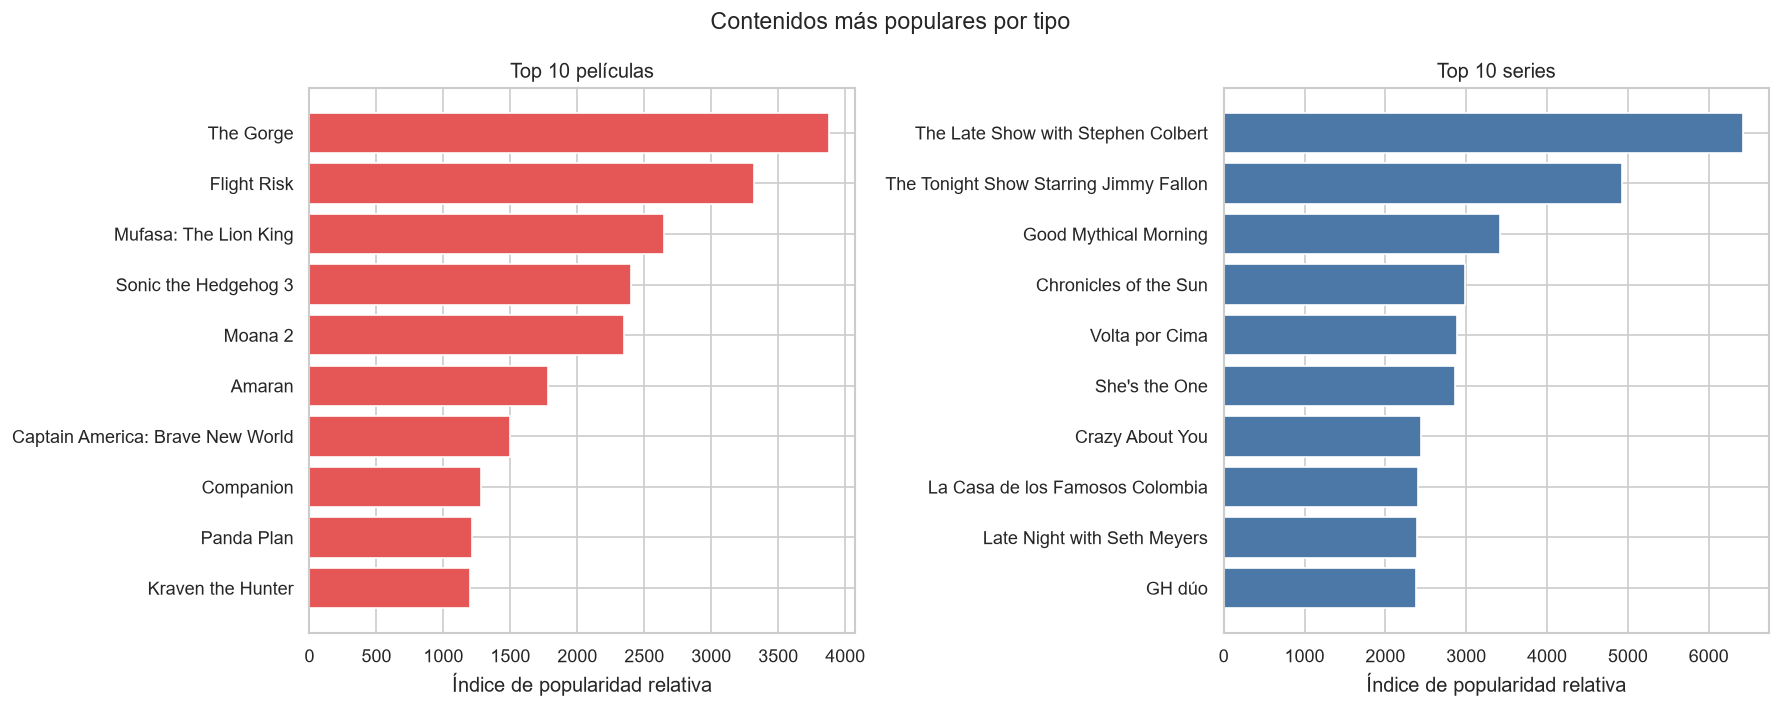

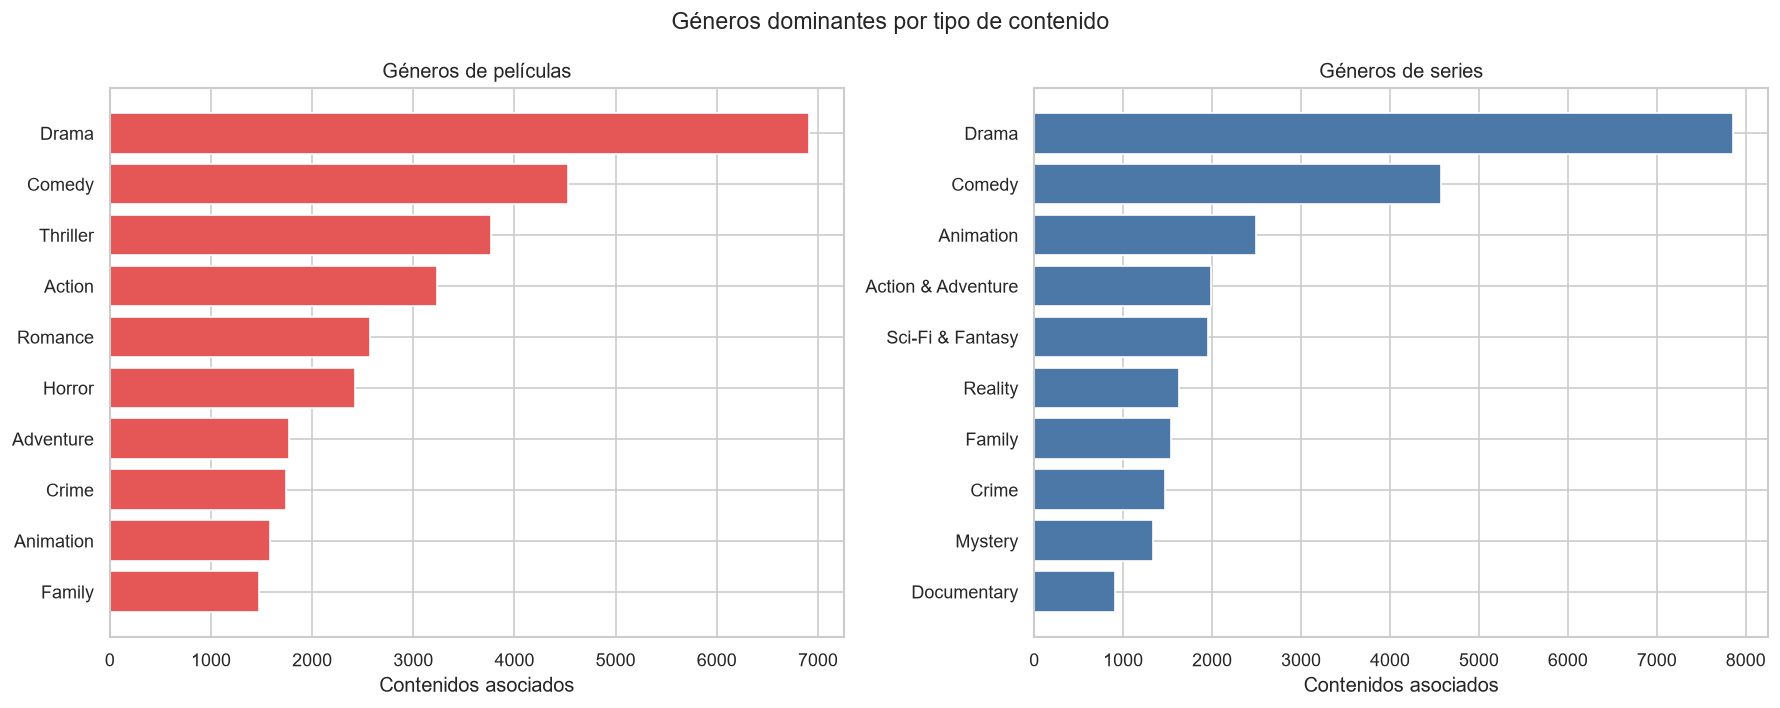

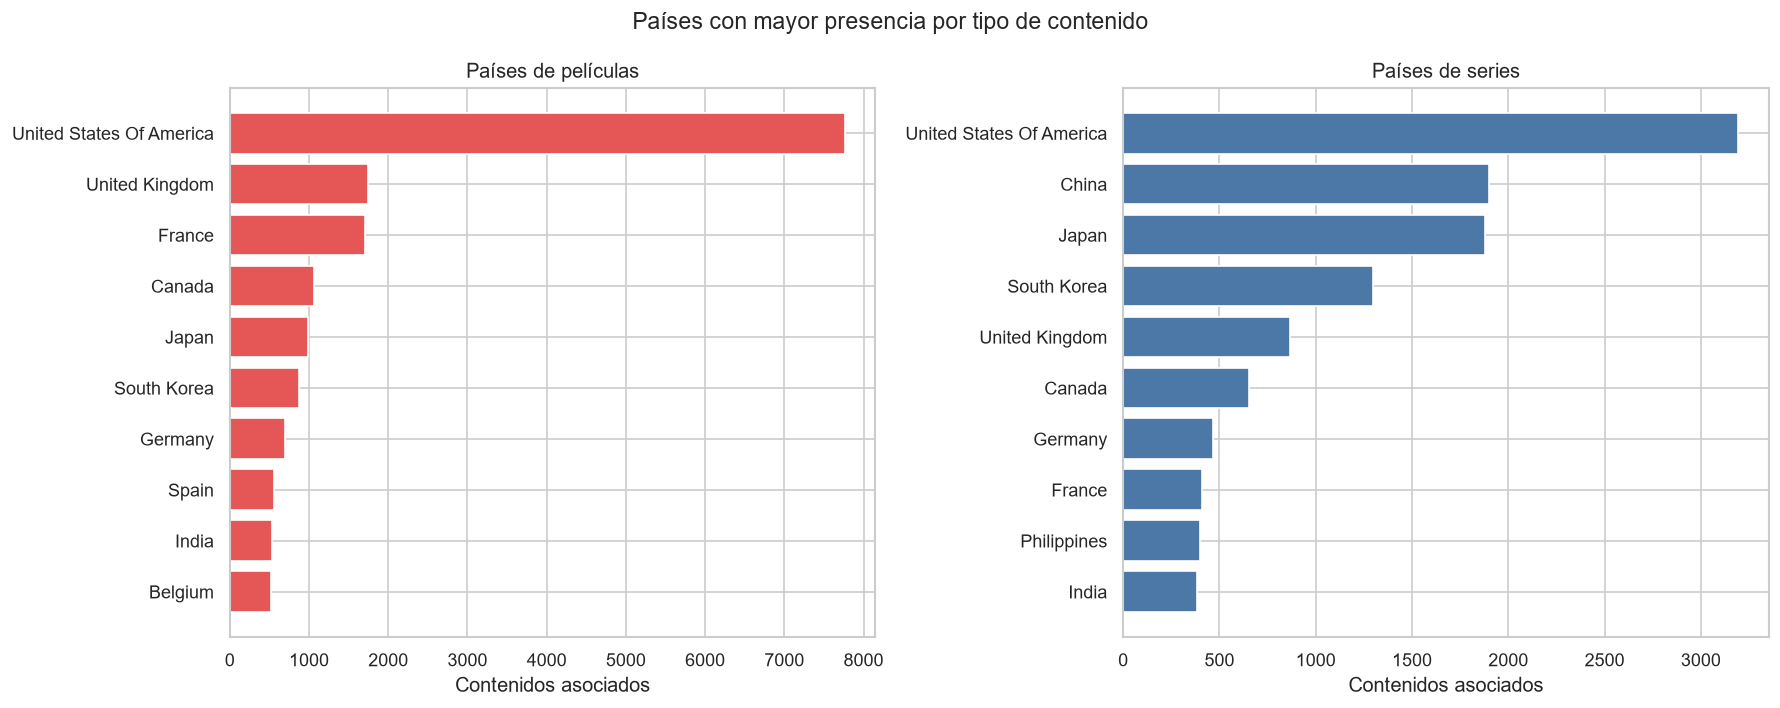

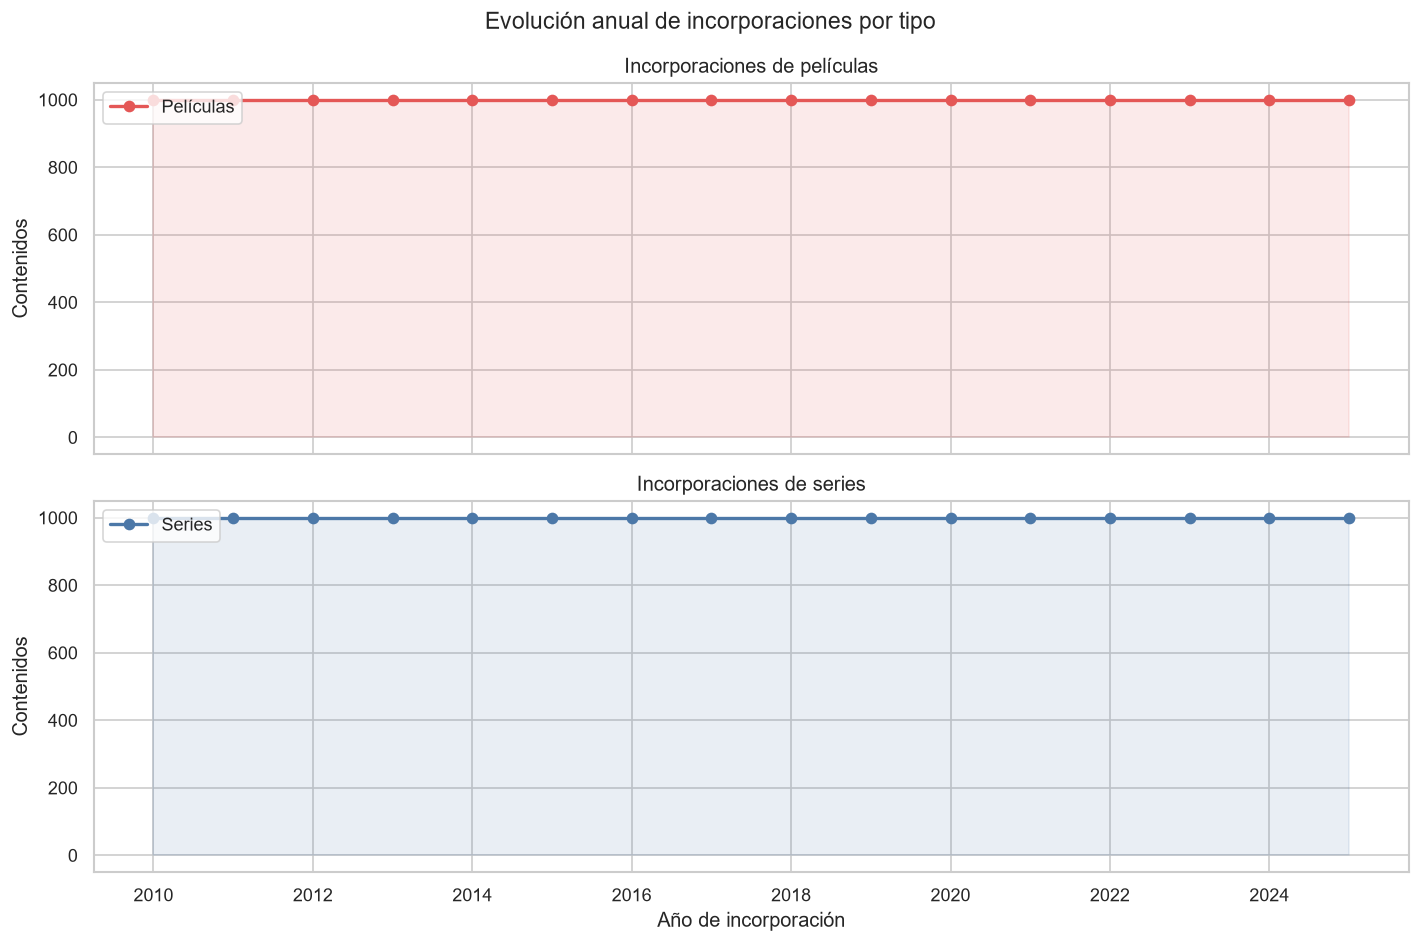

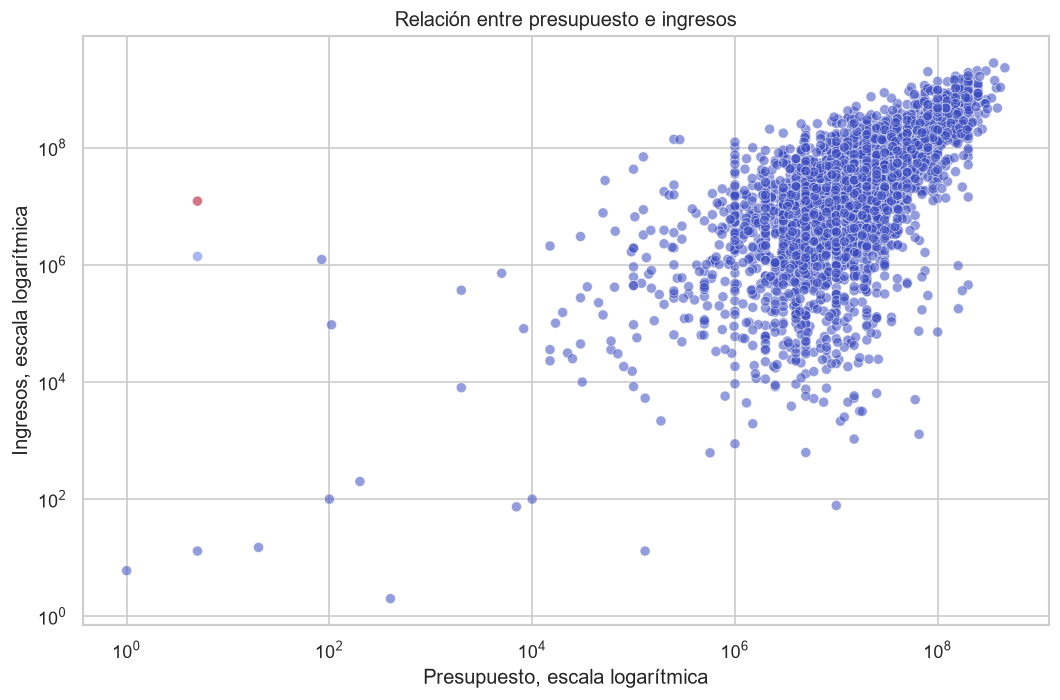

Tablas exportadas: 9 | Figuras exportadas: 5


In [14]:
# Visualizaciones comparativas preparadas para el futuro dashboard.
exports = {
    'kpis_catalogo.csv': kpi_table,
    'calidad_catalogo.csv': quality_table,
    'generos_resumen.csv': genre_summary.reset_index(),
    'paises_resumen.csv': country_summary.reset_index(),
    'idiomas_resumen.csv': language_counts.reset_index(),
    'top_popularidad.csv': top_popularity,
    'incorporacion_anual.csv': temporal_summary.reset_index(),
    'kpis_financieros.csv': financial_kpis.rename('valor').rename_axis('kpi').reset_index(),
    'mercados_prioritarios.csv': market_priority.reset_index(),
}
for filename, dataframe in exports.items():
    dataframe.to_csv(os.path.join(PROCESSED, filename), index=False)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120

COLORS = {'Movie': '#e45756', 'TV Show': '#4c78a8'}
LABELS = {'Movie': 'Películas', 'TV Show': 'Series'}

def save_plot(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES, filename), bbox_inches='tight')
    plt.show()

# 1) Popularidad por tipo: dos paneles evitan que una categoría oculte a la otra.
top_by_type = {}
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False)
for axis, content_type in zip(axes, ['Movie', 'TV Show']):
    subset = catalog[catalog.type.eq(content_type)].dropna(subset=['popularity']).nlargest(10, 'popularity').sort_values('popularity')
    top_by_type[content_type] = subset[['title', 'type', 'popularity', 'vote_average', 'vote_count', 'release_year']]
    axis.barh(subset.title, subset.popularity, color=COLORS[content_type])
    axis.set_title(f'Top 10 {LABELS[content_type].lower()}')
    axis.set_xlabel('Índice de popularidad relativa')
    axis.set_ylabel('')
fig.suptitle('Contenidos más populares por tipo', fontsize=14)
save_plot('eda_01_popularidad_por_tipo.png')

# 2) Géneros dominantes por tipo: muestra volumen y permite comparar composición temática.
genre_by_type = genres[genres.genres.ne('Sin información')].groupby(['genres', 'type']).agg(
    contenidos=('show_id', 'nunique'), popularidad_promedio=('popularity', 'mean')
).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False)
for axis, content_type in zip(axes, ['Movie', 'TV Show']):
    subset = genre_by_type[genre_by_type.type.eq(content_type)].nlargest(10, 'contenidos').sort_values('contenidos')
    axis.barh(subset.genres, subset.contenidos, color=COLORS[content_type])
    axis.set_title(f'Géneros de {LABELS[content_type].lower()}')
    axis.set_xlabel('Contenidos asociados')
    axis.set_ylabel('')
fig.suptitle('Géneros dominantes por tipo de contenido', fontsize=14)
save_plot('eda_02_generos_por_tipo.png')

# 3) Países por tipo: identifica mercados fuertes y espacios de expansión.
country_by_type = countries[countries.country.ne('Sin información')].groupby(['country', 'type']).agg(
    contenidos=('show_id', 'nunique'), popularidad_promedio=('popularity', 'mean')
).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False)
for axis, content_type in zip(axes, ['Movie', 'TV Show']):
    subset = country_by_type[country_by_type.type.eq(content_type)].nlargest(10, 'contenidos').sort_values('contenidos')
    axis.barh(subset.country, subset.contenidos, color=COLORS[content_type])
    axis.set_title(f'Países de {LABELS[content_type].lower()}')
    axis.set_xlabel('Contenidos asociados')
    axis.set_ylabel('')
fig.suptitle('Países con mayor presencia por tipo de contenido', fontsize=14)
save_plot('eda_03_paises_por_tipo.png')

# 4) Evolución temporal por tipo: paneles separados hacen visible cada línea.
temporal_by_type = catalog.dropna(subset=['added_year']).groupby(['added_year', 'type']).size().unstack(fill_value=0)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)
for axis, content_type in zip(axes, ['Movie', 'TV Show']):
    series = temporal_by_type.get(content_type, pd.Series(dtype='int64'))
    axis.plot(series.index, series.values, marker='o', linewidth=2, color=COLORS[content_type], label=LABELS[content_type])
    axis.fill_between(series.index, series.values, alpha=0.12, color=COLORS[content_type])
    axis.set_title(f'Incorporaciones de {LABELS[content_type].lower()}')
    axis.set_ylabel('Contenidos')
    axis.legend(loc='upper left')
axes[-1].set_xlabel('Año de incorporación')
fig.suptitle('Evolución anual de incorporaciones por tipo', fontsize=14)
save_plot('eda_04_temporal_por_tipo.png')

# 5) Finanzas: escala logarítmica para comparar rangos monetarios amplios.
fig, axis = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=financial, x='budget', y='revenue', hue='roi_approx', palette='coolwarm', alpha=.55, legend=False, ax=axis)
axis.set_xscale('log')
axis.set_yscale('log')
axis.set_title('Relación entre presupuesto e ingresos')
axis.set_xlabel('Presupuesto, escala logarítmica')
axis.set_ylabel('Ingresos, escala logarítmica')
save_plot('eda_05_finanzas.png')

# Dataset separado por tipo para alimentar filtros y gráficos del dashboard.
for content_type, dataframe in top_by_type.items():
    dataframe.to_csv(os.path.join(PROCESSED, f'top_popularidad_{content_type.lower().replace(" ", "_")}.csv'), index=False)
print(f'Tablas exportadas: {len(exports)} | Figuras exportadas: 5')

In [15]:
# Matriz de planificación para el dashboard: cada visual debe apoyar una decisión.
dashboard_visual_plan = pd.DataFrame([
    {
        'audiencia': 'Directorio',
        'pregunta': '¿Cómo se compone el catálogo?',
        'visual_recomendado': 'KPI cards + barras comparativas',
        'variables': 'type, contenidos',
        'filtros': 'periodo, país, género',
        'decision': 'balancear inversión entre películas y series',
        'prioridad': 'Alta',
    },
    {
        'audiencia': 'Marketing',
        'pregunta': '¿Qué títulos tienen mayor interés relativo?',
        'visual_recomendado': 'ranking horizontal con selector de tipo',
        'variables': 'title, popularity, vote_average, vote_count',
        'filtros': 'Movie/TV Show, país, género, año',
        'decision': 'seleccionar títulos para campañas',
        'prioridad': 'Alta',
    },
    {
        'audiencia': 'Contenidos',
        'pregunta': '¿Qué géneros dominan en cada tipo?',
        'visual_recomendado': 'barras agrupadas o small multiples',
        'variables': 'genres, type, contenidos, popularidad_promedio',
        'filtros': 'tipo, país, idioma',
        'decision': 'detectar saturación y espacios de adquisición',
        'prioridad': 'Alta',
    },
    {
        'audiencia': 'Contenidos',
        'pregunta': '¿Qué mercados tienen oferta y oportunidad?',
        'visual_recomendado': 'mapa coroplético + tabla de priorización',
        'variables': 'country, contenidos, oportunidad_proxy',
        'filtros': 'tipo, género, idioma, mínimo de contenidos',
        'decision': 'priorizar investigación de mercados',
        'prioridad': 'Alta',
    },
    {
        'audiencia': 'Directorio',
        'pregunta': '¿Cómo se relacionan presupuesto e ingresos?',
        'visual_recomendado': 'dispersión logarítmica con línea de referencia',
        'variables': 'budget, revenue, roi_approx',
        'filtros': 'año, rango de presupuesto, ROI',
        'decision': 'evaluar riesgo financiero de adquisiciones',
        'prioridad': 'Media',
    },
    {
        'audiencia': 'Contenidos',
        'pregunta': '¿Cómo cambia el catálogo en el tiempo?',
        'visual_recomendado': 'líneas separadas por tipo + selector temporal',
        'variables': 'added_year, type, contenidos',
        'filtros': 'rango de años, tipo',
        'decision': 'identificar cambios de estrategia de incorporación',
        'prioridad': 'Media',
    },
])
dashboard_visual_plan.to_csv(os.path.join(PROCESSED, 'dashboard_visual_plan.csv'), index=False)
print('Plan de visualizaciones exportado:', os.path.join(PROCESSED, 'dashboard_visual_plan.csv'))
print(dashboard_visual_plan.to_string(index=False))

Plan de visualizaciones exportado: c:\Users\shein\OneDrive\Documentos\GitHub\visualizacion-de-datos-StreamView-Analytics\data\processed\dashboard_visual_plan.csv
 audiencia                                    pregunta                             visual_recomendado                                      variables                                    filtros                                           decision prioridad
Directorio               ¿Cómo se compone el catálogo?                KPI cards + barras comparativas                               type, contenidos                      periodo, país, género       balancear inversión entre películas y series      Alta
 Marketing ¿Qué títulos tienen mayor interés relativo?        ranking horizontal con selector de tipo    title, popularity, vote_average, vote_count           Movie/TV Show, país, género, año                  seleccionar títulos para campañas      Alta
Contenidos          ¿Qué géneros dominan en cada tipo?             barras agrup

## Interpretación y comunicación

- **Directorio:** el catálogo es amplio, pero concentrado en pocos géneros y países; las decisiones financieras deben considerar el ROI mediano negativo.
- **Contenidos:** Drama y Comedy lideran; las asociaciones de género y país no duplican el KPI de contenidos.
- **Marketing:** la popularidad permite priorizar títulos y mercados, pero debe combinarse con `vote_count`, `vote_average` y validación local.
- **Mercados:** el proxy combina popularidad normalizada y baja participación del catálogo, con mínimo de 30 contenidos; no es una predicción de demanda.
- **Visualización:** barras para comparar categorías, ranking horizontal para títulos largos, línea para evolución y dispersión logarítmica para escalas financieras.
- **Limitaciones:** hay valores faltantes; `show_id` puede repetirse entre fuentes; las finanzas solo incluyen películas con `budget`, `revenue` válidos y `budget > 0`; la correlación no demuestra causalidad.

El código exporta el informe narrativo `documentation/markdown/analysis_eda_catalogo.md` mediante la siguiente celda.

In [13]:
top_genre = genre_summary.index[0]
top_market = market_priority.index[0] if len(market_priority) else 'No determinado'
latam = ', '.join([name for name in ['Brazil', 'Colombia', 'Chile', 'Mexico'] if name in market_summary.index]) or 'sin cobertura suficiente'
report_path = os.path.join(DOCS, 'analysis_eda_catalogo.md')
with open(report_path, 'w', encoding='utf-8') as report:
    report.write(f'''---\ntitle: 'EDA completo - StreamView Analytics'\nauthor: 'Equipo StreamView - Data Analyst / Visual Designer'\ndate: 2026-08-28\nsource_files:\n  - notebooks/EP1_eda_catalogo.ipynb\n  - data/processed/movies_processed.csv\n  - data/processed/tv_processed.csv\n---\n\n## Resumen ejecutivo\n\nEl catálogo contiene {len(catalog):,} contenidos, con {int((catalog.type == 'Movie').sum()):,} películas y {int((catalog.type == 'TV Show').sum()):,} series. {top_genre} es el género dominante. La correlación presupuesto-ingresos es {financial_kpis['Correlación budget-revenue']:.3f}, mientras el ROI mediano es {financial_kpis['ROI aproximado mediano']:.1%}.\n\n## Preguntas del caso\n\n- **Géneros predominantes:** {top_genre}, seguido por Comedy y Animation.\n- **Contenidos más populares:** {top_popularity.iloc[0].title}, con índice {top_popularity.iloc[0].popularity:.2f}; no equivale a reproducciones.\n- **Relación budget-revenue:** positiva en {len(financial):,} películas válidas, pero no causal.\n- **Mercados prioritarios:** el proxy identifica {top_market}; entre los mercados latinoamericanos aparecen {latam}.\n- **KPIs:** se exportan en data/processed/ junto con países, idiomas, géneros, popularidad, evolución y finanzas.\n\n## Reproducibilidad y limitaciones\n\nEjecutar primero `notebooks/EP1_initial_cleaning_colab.ipynb` y luego este notebook. Las figuras se guardan en `images/`. Se documentan nulos, duplicados entre fuentes, exclusiones financieras y el carácter relativo de `popularity`.\n''')
print(f'Informe generado: {report_path}')
print(f'Tablas exportadas: {len(exports)} | Figuras exportadas: 6')

Informe generado: c:\Users\shein\OneDrive\Documentos\GitHub\visualizacion-de-datos-StreamView-Analytics\documentation\markdown\analysis_eda_catalogo.md
Tablas exportadas: 9 | Figuras exportadas: 6


In [16]:
# Actualizar el informe con la selección visual vigente y sus decisiones de diseño.
from pathlib import Path

report_file = Path(report_path)
report_text = report_file.read_text(encoding='utf-8')
marker = '## Plan para el dashboard'
if marker in report_text:
    report_text = report_text.split(marker)[0].rstrip() + '\n'
report_text += f'''\n{marker}\n\nLa matriz completa se encuentra en `data/processed/dashboard_visual_plan.csv`. Se priorizan rankings de popularidad separados por tipo, géneros y países comparados entre películas y series, una línea temporal en paneles independientes y una dispersión financiera logarítmica. La composición general queda como KPI, no como gráfico independiente.\n\nLa serie temporal es plana porque el dataset contiene exactamente 1.000 películas y 1.000 series incorporadas en cada año entre 2010 y 2025. Debe interpretarse como una limitación de los datos.\n\n## Reproducibilidad\n\nEjecutar primero `notebooks/EP1_initial_cleaning_colab.ipynb` y después este notebook. Se generan 9 tablas, 5 figuras vigentes en `images/` y una matriz de planificación para construir el dashboard.\n'''
report_file.write_text(report_text, encoding='utf-8')
print(f'Informe actualizado: {report_file}')

Informe actualizado: c:\Users\shein\OneDrive\Documentos\GitHub\visualizacion-de-datos-StreamView-Analytics\documentation\markdown\analysis_eda_catalogo.md
